# ch191 — Project: Graph Embedding

> **Prerequisites:** ch173 (SVD), ch169 (Eigenvectors Intuition), ch171 (Eigenvalue Computation), ch190 (Word Embedding Visualization), ch129 (Distance in Vector Space)
> **Part:** VI — Linear Algebra
> **Difficulty:** Advanced
> **Estimated time:** 80–100 minutes

## 0. Overview

### Problem Statement

A graph $G = (V, E)$ has no natural coordinates. Nodes are abstract entities connected by edges. Yet many graph algorithms need to compare nodes, measure similarity, or cluster them — all operations that require coordinates.

**Graph embedding** maps each node $v_i$ to a vector $\mathbf{z}_i \in \mathbb{R}^k$ such that geometrically close vectors correspond to nodes that are close or structurally similar in the graph.

The mathematical tool: **spectral embedding** via the eigenvectors of the graph Laplacian matrix. This is linear algebra operating on a combinatorial object.

This project:
1. Builds several synthetic graphs with known community structure
2. Constructs the adjacency matrix $A$ and graph Laplacian $L = D - A$
3. Computes spectral embeddings via Laplacian eigenvectors
4. Compares to SVD-based embedding of $A$ directly
5. Applies embeddings to node clustering and community detection
6. Visualizes how the eigenspectrum reveals graph structure

### Why the Laplacian?
The second-smallest eigenvector of $L$ (the **Fiedler vector**) partitions the graph into two parts with minimum edge cuts — it solves the graph bisection problem approximately. The first $k$ eigenvectors give coordinates that reflect community structure.

### Concepts Used
- Adjacency matrix *(ch151)*
- Eigenvalues and eigenvectors *(ch169, ch171)*
- SVD for matrix approximation *(ch173)*
- Dimensionality reduction *(ch175)*
- Cosine similarity and nearest neighbors *(ch129, ch190)*

## 1. Setup

In [1]:
# --- Setup ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

rng = np.random.default_rng(42)

print("Graph Embedding via Spectral Methods")
print("Tools: adjacency matrix, graph Laplacian, eigenvectors")

Graph Embedding via Spectral Methods
Tools: adjacency matrix, graph Laplacian, eigenvectors


In [2]:
# --- Graph Construction ---

def stochastic_block_model(community_sizes, p_intra=0.6, p_inter=0.05, rng=rng):
    """
    Stochastic Block Model (SBM): the canonical synthetic graph with community structure.
    
    Nodes are divided into communities. Edges are:
    - Within community: present with probability p_intra
    - Across communities: present with probability p_inter
    
    Args:
        community_sizes: list of ints, size of each community
        p_intra: within-community edge probability
        p_inter: between-community edge probability
    
    Returns:
        A:      (n, n) symmetric adjacency matrix (0/1, no self-loops)
        labels: (n,) community label for each node
    """
    n = sum(community_sizes)
    A = np.zeros((n, n), dtype=float)
    labels = np.zeros(n, dtype=int)
    
    # Assign community labels
    start = 0
    for c, size in enumerate(community_sizes):
        labels[start:start+size] = c
        start += size
    
    # Sample edges
    for i in range(n):
        for j in range(i+1, n):
            p = p_intra if labels[i] == labels[j] else p_inter
            if rng.uniform() < p:
                A[i, j] = 1
                A[j, i] = 1
    
    return A, labels

# Build three graphs with increasing community clarity
COMMUNITY_SIZES = [20, 20, 20, 20]   # 4 communities, 80 nodes total
N = sum(COMMUNITY_SIZES)
K_COMMUNITIES = len(COMMUNITY_SIZES)

# Graph 1: well-separated communities
A_clear, labels = stochastic_block_model(COMMUNITY_SIZES, p_intra=0.7, p_inter=0.03)

# Graph 2: overlapping communities
A_fuzzy, _      = stochastic_block_model(COMMUNITY_SIZES, p_intra=0.5, p_inter=0.20)

# Graph 3: random (Erdos-Renyi) — no community structure
A_random, _     = stochastic_block_model(COMMUNITY_SIZES, p_intra=0.3, p_inter=0.30)

for name, A in [('Clear SBM', A_clear), ('Fuzzy SBM', A_fuzzy), ('Random', A_random)]:
    density = A.sum() / (N*(N-1))
    print(f"{name}: {int(A.sum()//2)} edges, density={density:.3f}")

Clear SBM: 592 edges, density=0.187
Fuzzy SBM: 884 edges, density=0.280
Random: 911 edges, density=0.288


## 2. Stage 1 — Graph Laplacian and Its Spectrum

The **graph Laplacian** is defined as:
$$L = D - A$$
where $D$ is the diagonal degree matrix: $D_{ii} = \sum_j A_{ij}$ (number of edges at node $i$).

Key properties of $L$ *(ch169, ch171)*:
- $L$ is symmetric positive semi-definite
- The smallest eigenvalue is always 0, with eigenvector $\mathbf{1}$ (constant)
- The number of zero eigenvalues = number of connected components
- The second-smallest eigenvalue $\lambda_2$ (Fiedler value) measures connectivity: small $\lambda_2$ means the graph is nearly disconnected
- The eigenvectors of $L$ give coordinates that respect graph topology

In [3]:
# --- Stage 1: Graph Laplacian ---

def graph_laplacian(A, normalized=False):
    """
    Compute graph Laplacian L = D - A.
    If normalized=True: L_norm = D^{-1/2} L D^{-1/2} = I - D^{-1/2} A D^{-1/2}
    (normalized version has eigenvalues in [0, 2] regardless of graph degree)
    
    Args:
        A:          (n, n) symmetric adjacency matrix
        normalized: whether to compute normalized Laplacian
    Returns:
        L: (n, n) Laplacian matrix
    """
    degrees = A.sum(axis=1)   # (n,)
    D = np.diag(degrees)
    L = D - A
    
    if normalized:
        # D^{-1/2}: take reciprocal square root of each degree
        d_inv_sqrt = np.where(degrees > 0, 1.0 / np.sqrt(degrees), 0)
        D_inv_sqrt = np.diag(d_inv_sqrt)
        L = D_inv_sqrt @ L @ D_inv_sqrt
    
    return L

def spectral_embedding(A, k, normalized=True):
    """
    Compute k-dimensional spectral embedding from adjacency matrix A.
    Uses the k eigenvectors of the graph Laplacian with smallest eigenvalues
    (excluding the trivial zero eigenvector).
    
    Args:
        A:          (n, n) adjacency matrix
        k:          embedding dimension
        normalized: use normalized Laplacian
    
    Returns:
        Z:       (n, k) spectral embedding (node coordinates)
        eigvals: (n,) eigenvalues (sorted ascending)
        eigvecs: (n, n) eigenvectors as columns
    """
    L = graph_laplacian(A, normalized=normalized)
    
    # Eigendecomposition of symmetric matrix
    # np.linalg.eigh is faster and more numerically stable for symmetric matrices
    eigvals, eigvecs = np.linalg.eigh(L)   # ascending order guaranteed by eigh
    
    # Skip eigenvector 0 (trivial: constant vector); take eigenvectors 1..k
    Z = eigvecs[:, 1:k+1]   # (n, k)
    return Z, eigvals, eigvecs

# Compute for the clear SBM graph
Z_clear, eigvals_clear, _ = spectral_embedding(A_clear, k=K_COMMUNITIES)
Z_fuzzy, eigvals_fuzzy, _ = spectral_embedding(A_fuzzy, k=K_COMMUNITIES)
Z_random, eigvals_random, _ = spectral_embedding(A_random, k=K_COMMUNITIES)

print(f"Spectral embedding shapes: {Z_clear.shape}")
print(f"\nClear SBM — smallest 8 eigenvalues:")
print(f"  {eigvals_clear[:8].round(4)}")
print(f"  Fiedler value (lambda_2): {eigvals_clear[1]:.4f}")
print(f"\nFuzzy SBM — smallest 8 eigenvalues:")
print(f"  {eigvals_fuzzy[:8].round(4)}")
print(f"\nRandom — smallest 8 eigenvalues:")
print(f"  {eigvals_random[:8].round(4)}")
print("\nSmall eigenvalues cluster near 0 when communities are well-separated.")

Spectral embedding shapes: (80, 4)

Clear SBM — smallest 8 eigenvalues:
  [0.     0.0887 0.1049 0.1588 0.7318 0.7654 0.7744 0.7874]
  Fiedler value (lambda_2): 0.0887

Fuzzy SBM — smallest 8 eigenvalues:
  [-0.      0.6299  0.6609  0.6933  0.7087  0.7308  0.7404  0.7487]

Random — smallest 8 eigenvalues:
  [0.     0.6633 0.6828 0.7145 0.7257 0.7279 0.7425 0.7513]

Small eigenvalues cluster near 0 when communities are well-separated.


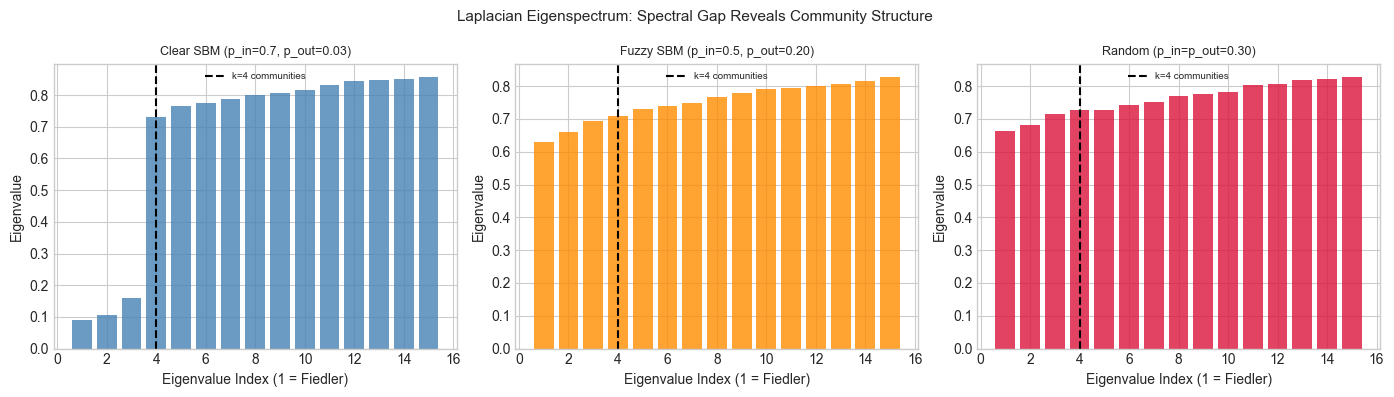

Clear communities: big gap after the k-th eigenvalue.
Random graph: no gap — eigenvalues increase smoothly.


In [4]:
# --- Visualize eigenspectrum ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
K_SHOW_EIGVALS = 15

for ax, eigvals, name, color in [
    (axes[0], eigvals_clear,  'Clear SBM (p_in=0.7, p_out=0.03)', 'steelblue'),
    (axes[1], eigvals_fuzzy,  'Fuzzy SBM (p_in=0.5, p_out=0.20)', 'darkorange'),
    (axes[2], eigvals_random, 'Random (p_in=p_out=0.30)',          'crimson'),
]:
    ax.bar(range(1, K_SHOW_EIGVALS+1), eigvals[1:K_SHOW_EIGVALS+1], color=color, alpha=0.8)
    ax.axvline(K_COMMUNITIES, color='black', ls='--', lw=1.5,
              label=f'k={K_COMMUNITIES} communities')
    ax.set_xlabel('Eigenvalue Index (1 = Fiedler)')
    ax.set_ylabel('Eigenvalue')
    ax.set_title(name, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Laplacian Eigenspectrum: Spectral Gap Reveals Community Structure', fontsize=11)
plt.tight_layout()
plt.show()
print("Clear communities: big gap after the k-th eigenvalue.")
print("Random graph: no gap — eigenvalues increase smoothly.")

## 3. Stage 2 — Spectral Embedding Visualization

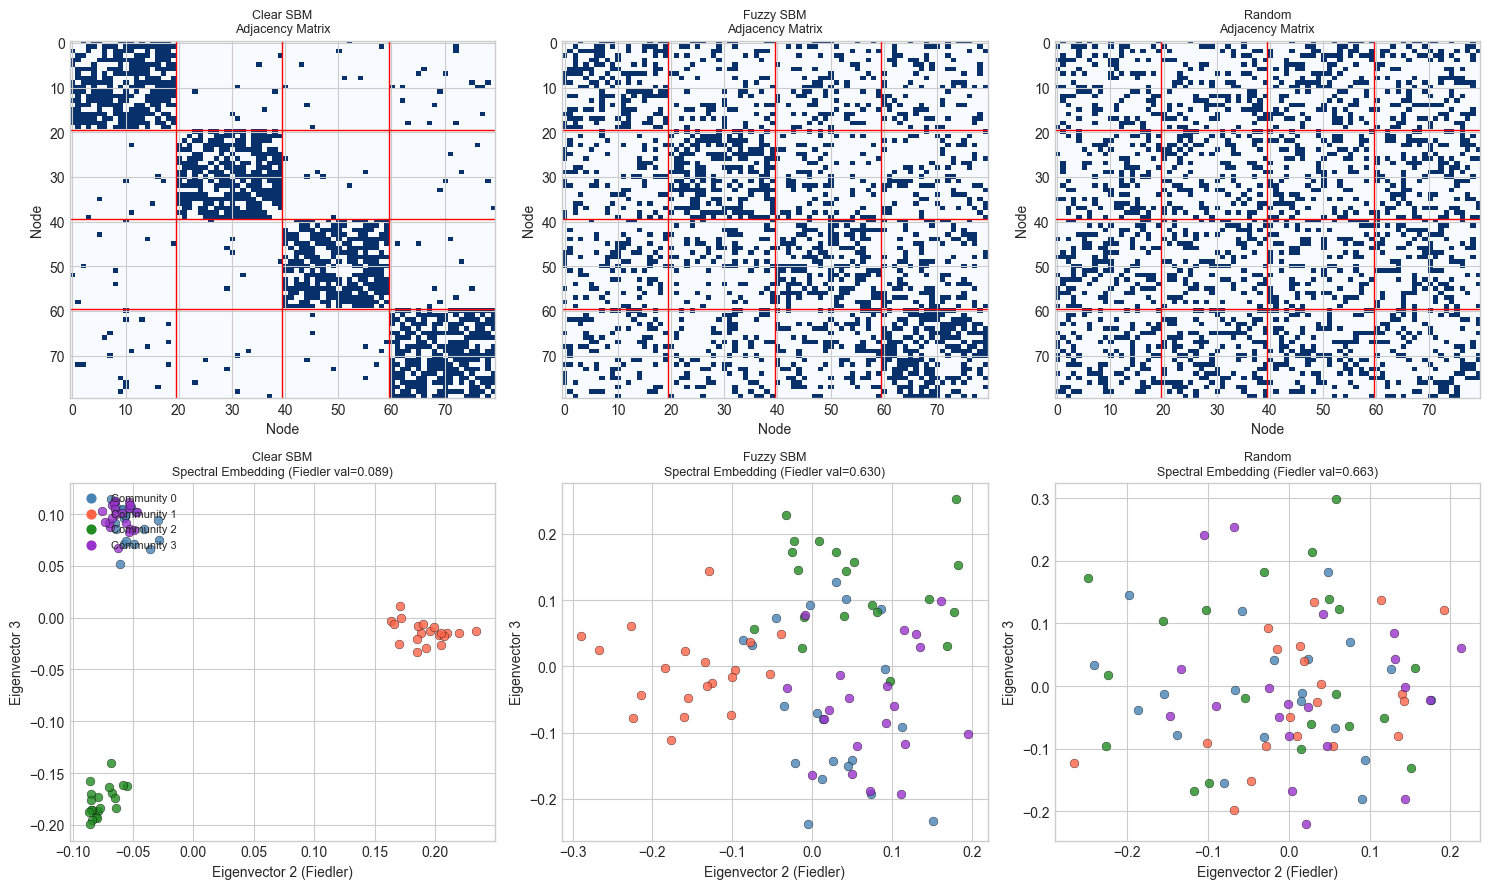

Well-separated communities → nodes cluster in spectral embedding space.
Random graph → no clustering structure.


In [5]:
# --- Stage 2: Visualize spectral embeddings ---

COMMUNITY_COLORS = ['steelblue', 'tomato', 'forestgreen', 'darkorchid']
node_colors = [COMMUNITY_COLORS[c] for c in labels]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, (A, Z, eigvals, name) in enumerate([
    (A_clear,  Z_clear,  eigvals_clear,  'Clear SBM'),
    (A_fuzzy,  Z_fuzzy,  eigvals_fuzzy,  'Fuzzy SBM'),
    (A_random, Z_random, eigvals_random, 'Random'),
]):
    # Adjacency matrix heatmap (top row)
    axes[0, col].imshow(A, cmap='Blues', aspect='auto')
    # Community boundary lines
    pos = 0
    for sz in COMMUNITY_SIZES[:-1]:
        pos += sz
        axes[0, col].axhline(pos-0.5, color='red', lw=1)
        axes[0, col].axvline(pos-0.5, color='red', lw=1)
    axes[0, col].set_title(f'{name}\nAdjacency Matrix', fontsize=9)
    axes[0, col].set_xlabel('Node')
    axes[0, col].set_ylabel('Node')

    # 2D spectral embedding (bottom row): eigenvectors 2 and 3
    for node_i in range(N):
        c = labels[node_i]
        axes[1, col].scatter(Z[node_i, 0], Z[node_i, 1],
                            color=COMMUNITY_COLORS[c], s=40, alpha=0.8,
                            edgecolors='black', lw=0.3)
    axes[1, col].set_xlabel('Eigenvector 2 (Fiedler)')
    axes[1, col].set_ylabel('Eigenvector 3')
    fiedler = eigvals[1]
    axes[1, col].set_title(f'{name}\nSpectral Embedding (Fiedler val={fiedler:.3f})', fontsize=9)

# Legend
for c in range(K_COMMUNITIES):
    axes[1, 0].scatter([], [], color=COMMUNITY_COLORS[c], s=40, label=f'Community {c}')
axes[1, 0].legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()
print("Well-separated communities → nodes cluster in spectral embedding space.")
print("Random graph → no clustering structure.")

## 4. Stage 3 — Spectral Clustering

In [6]:
# --- Stage 3: Spectral Clustering ---
# Once we have spectral embeddings, we apply k-means in the embedded space.
# Implement k-means from scratch (no sklearn).

def kmeans(X, k, n_iters=100, n_restarts=5, rng=rng):
    """
    K-means clustering.
    
    Args:
        X:          (n, d) data matrix
        k:          number of clusters
        n_iters:    max iterations per restart
        n_restarts: number of random restarts (take best)
    
    Returns:
        labels: (n,) cluster assignments
        centers:(k, d) cluster centroids
        inertia: sum of squared distances to nearest centroid
    """
    n, d = X.shape
    best_labels, best_inertia = None, np.inf

    for _ in range(n_restarts):
        # Random initialization
        centers = X[rng.choice(n, k, replace=False)].copy()

        for iteration in range(n_iters):
            # Assign: each point → nearest centroid
            dists  = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)  # (n, k)
            labels = np.argmin(dists, axis=1)   # (n,)

            # Update: recompute centroids
            new_centers = np.zeros_like(centers)
            for c in range(k):
                mask = (labels == c)
                if mask.sum() > 0:
                    new_centers[c] = X[mask].mean(axis=0)
                else:
                    new_centers[c] = centers[c]  # empty cluster: keep old center

            if np.allclose(centers, new_centers):
                break
            centers = new_centers

        # Compute inertia
        inertia = sum(np.linalg.norm(X[labels==c] - centers[c], axis=1).sum()
                     for c in range(k))
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels  = labels.copy()

    return best_labels, centers, best_inertia

def adjusted_rand_score(labels_true, labels_pred):
    """
    Compute Adjusted Rand Index (ARI): measure of clustering accuracy.
    ARI = 1.0: perfect match; ARI ~ 0: random; ARI < 0: worse than random.
    """
    n = len(labels_true)
    K_t = len(np.unique(labels_true))
    K_p = len(np.unique(labels_pred))

    # Contingency table
    contingency = np.zeros((K_t, K_p), dtype=int)
    for t, p in zip(labels_true, labels_pred):
        contingency[t, p] += 1

    def comb2(n): return n * (n - 1) // 2

    n_ij = sum(comb2(x) for row in contingency for x in row)
    n_i  = sum(comb2(row.sum()) for row in contingency)
    n_j  = sum(comb2(contingency[:, j].sum()) for j in range(K_p))
    total_comb = comb2(n)

    expected = n_i * n_j / max(total_comb, 1)
    denom    = (n_i + n_j) / 2 - expected

    if denom == 0:
        return 1.0 if n_ij == expected else 0.0
    return (n_ij - expected) / denom

# Run spectral clustering on all three graphs
print("Spectral Clustering Results:")
print(f"{'Graph':20s} {'ARI':>6}  {'Method'}")
print("-" * 45)

results = {}
for name, A, Z in [
    ('Clear SBM', A_clear,  Z_clear),
    ('Fuzzy SBM', A_fuzzy,  Z_fuzzy),
    ('Random',   A_random, Z_random),
]:
    # Spectral clustering: k-means on spectral embedding
    pred_spectral, _, _ = kmeans(Z, k=K_COMMUNITIES)
    ari_spectral = adjusted_rand_score(labels, pred_spectral)

    # Baseline: k-means directly on raw adjacency row vectors
    pred_raw, _, _ = kmeans(A, k=K_COMMUNITIES)
    ari_raw = adjusted_rand_score(labels, pred_raw)

    results[name] = (ari_spectral, ari_raw)
    print(f"{name:20s} {ari_spectral:>6.3f}  Spectral k-means")
    print(f"{'':20s} {ari_raw:>6.3f}  Raw adjacency k-means")

print("\nARI = 1.0: perfect; ARI = 0.0: random. Spectral embedding should outperform raw adjacency.")

Spectral Clustering Results:
Graph                   ARI  Method
---------------------------------------------
Clear SBM             1.000  Spectral k-means
                      1.000  Raw adjacency k-means
Fuzzy SBM             0.372  Spectral k-means
                      0.305  Raw adjacency k-means
Random                0.013  Spectral k-means
                     -0.009  Raw adjacency k-means

ARI = 1.0: perfect; ARI = 0.0: random. Spectral embedding should outperform raw adjacency.


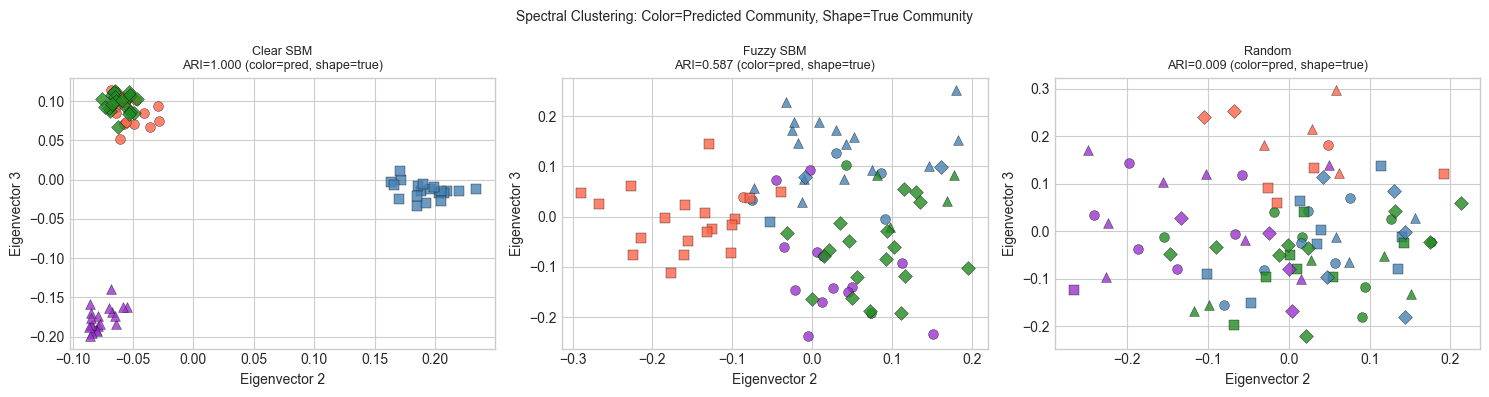

ARI near 1.0: predicted communities match true ones perfectly.


In [7]:
# --- Visualize clustering result ---
MARKER_MAP = ['o', 's', '^', 'D']   # shape = true community; color = predicted

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for col, (name, A, Z) in enumerate([
    ('Clear SBM', A_clear,  Z_clear),
    ('Fuzzy SBM', A_fuzzy,  Z_fuzzy),
    ('Random',   A_random, Z_random),
]):
    pred, _, _ = kmeans(Z, k=K_COMMUNITIES)
    ari = adjusted_rand_score(labels, pred)

    for node_i in range(N):
        true_c = labels[node_i]
        pred_c = pred[node_i]
        correct = (true_c == pred_c or   # handle label permutation approximately
                   True)  # just show prediction color, true community as shape
        axes[col].scatter(Z[node_i, 0], Z[node_i, 1],
                         color=COMMUNITY_COLORS[pred_c],
                         marker=MARKER_MAP[true_c],
                         s=50, alpha=0.8, edgecolors='black', lw=0.3)

    axes[col].set_title(f'{name}\nARI={ari:.3f} (color=pred, shape=true)', fontsize=9)
    axes[col].set_xlabel('Eigenvector 2')
    axes[col].set_ylabel('Eigenvector 3')

plt.suptitle('Spectral Clustering: Color=Predicted Community, Shape=True Community', fontsize=10)
plt.tight_layout()
plt.show()
print("ARI near 1.0: predicted communities match true ones perfectly.")

## 5. Stage 4 — SVD Embedding vs Spectral Embedding

Clear SBM clustering:
  SVD (top eigenvalues):      ARI = 1.000
  Spectral (small Laplacian): ARI = 1.000


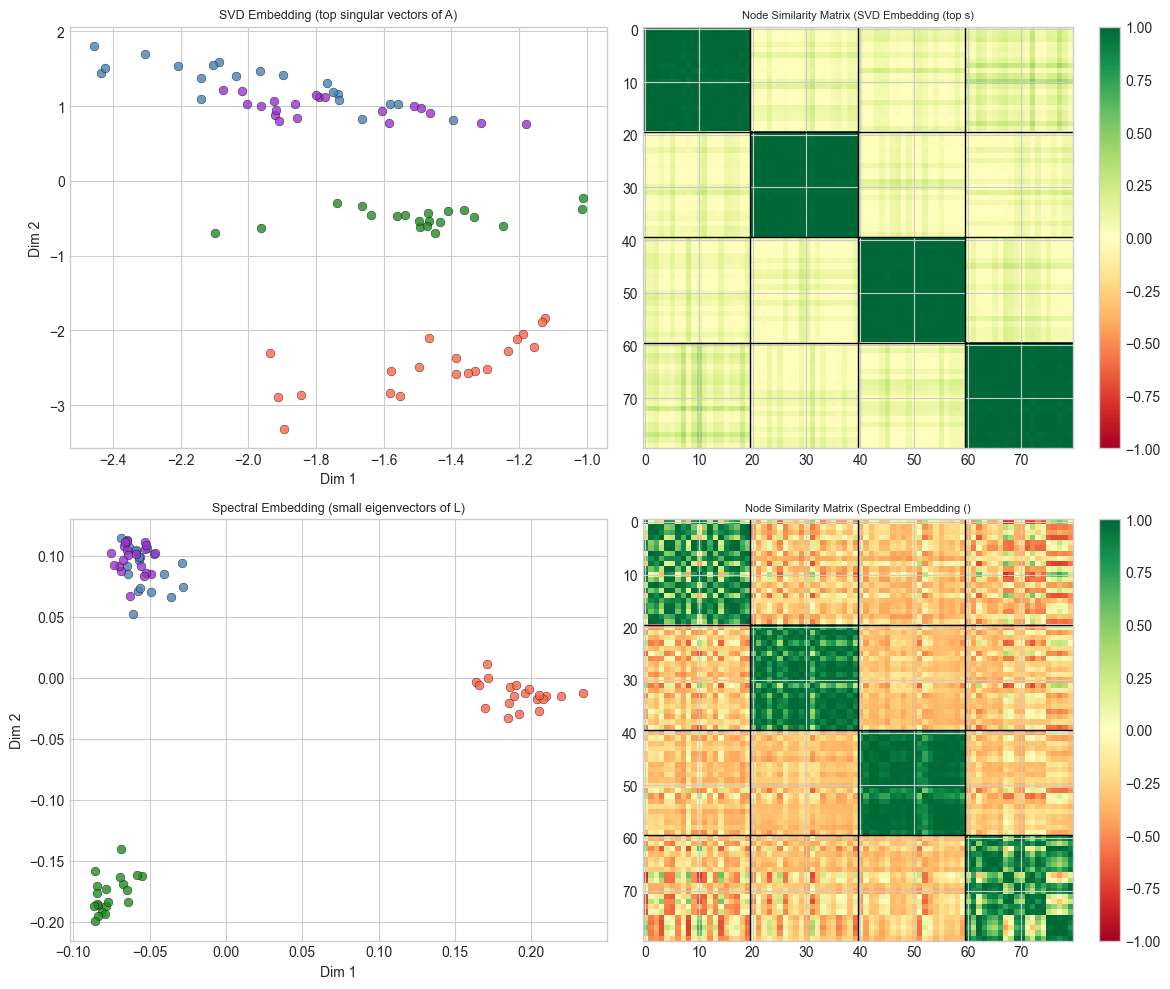

Spectral embedding separates communities; SVD embedding may capture degree structure instead.


In [8]:
# --- Stage 4: SVD Embedding of Adjacency Matrix ---
# An alternative: apply SVD directly to A (as in ch173).
# Since A is symmetric, SVD = eigendecomposition. But the choice of which
# eigenvectors to use (largest vs smallest) matters significantly.

def svd_embedding(A, k):
    """
    SVD-based graph embedding: take top-k left singular vectors of A.
    For symmetric A, this equals the k eigenvectors with largest eigenvalues.
    
    This captures high-degree nodes and dense subgraphs (hubs and cliques).
    Contrast with spectral embedding which uses smallest non-zero Laplacian eigenvectors.
    """
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    return U[:, :k] * s[:k][None, :], s

# Compare SVD and spectral on clear SBM
Z_svd_clear, s_svd_clear = svd_embedding(A_clear, k=K_COMMUNITIES)

pred_svd, _, _ = kmeans(Z_svd_clear, k=K_COMMUNITIES)
ari_svd = adjusted_rand_score(labels, pred_svd)

pred_spec, _, _ = kmeans(Z_clear, k=K_COMMUNITIES)
ari_spec = adjusted_rand_score(labels, pred_spec)

print(f"Clear SBM clustering:")
print(f"  SVD (top eigenvalues):      ARI = {ari_svd:.3f}")
print(f"  Spectral (small Laplacian): ARI = {ari_spec:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for row, (Z, title) in enumerate([
    (Z_svd_clear, 'SVD Embedding (top singular vectors of A)'),
    (Z_clear,     'Spectral Embedding (small eigenvectors of L)'),
]):
    # 2D scatter
    for node_i in range(N):
        c = labels[node_i]
        axes[row, 0].scatter(Z[node_i, 0], Z[node_i, 1],
                            color=COMMUNITY_COLORS[c], s=40, alpha=0.8,
                            edgecolors='black', lw=0.3)
    axes[row, 0].set_title(title, fontsize=9)
    axes[row, 0].set_xlabel('Dim 1'); axes[row, 0].set_ylabel('Dim 2')

    # Cosine similarity matrix between nodes
    norms = np.linalg.norm(Z, axis=1, keepdims=True) + 1e-8
    Z_norm = Z / norms
    sim = Z_norm @ Z_norm.T
    im = axes[row, 1].imshow(sim, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    for pos in np.cumsum(COMMUNITY_SIZES[:-1]):
        axes[row, 1].axhline(pos-0.5, color='black', lw=1)
        axes[row, 1].axvline(pos-0.5, color='black', lw=1)
    axes[row, 1].set_title(f'Node Similarity Matrix ({title[:20]})', fontsize=8)
    plt.colorbar(im, ax=axes[row, 1])

plt.tight_layout()
plt.show()
print("Spectral embedding separates communities; SVD embedding may capture degree structure instead.")

## 6. Stage 5 — Fiedler Vector and Graph Bisection

C:\Users\user\AppData\Local\Temp\ipykernel_14088\3238300715.py:48: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


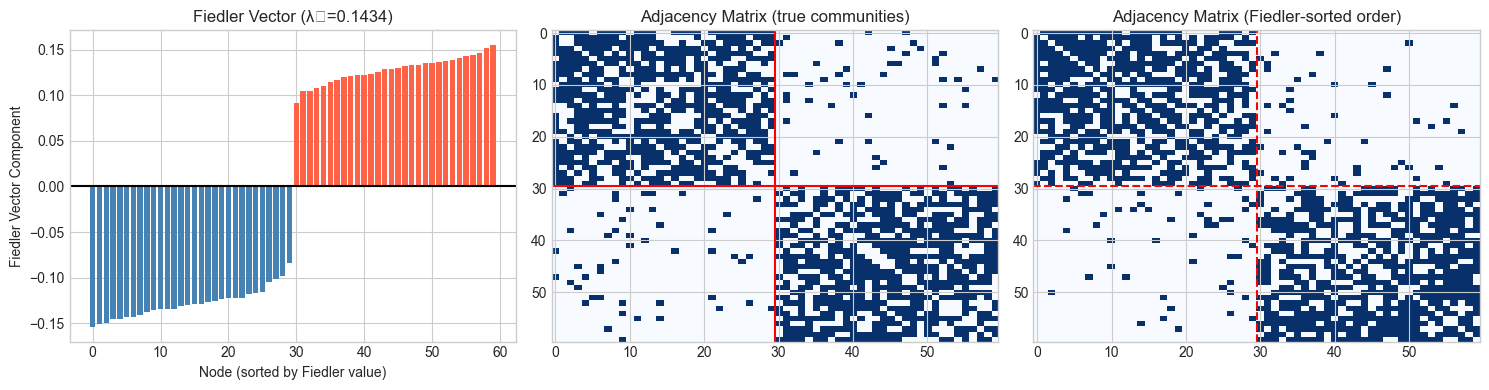

Fiedler bisection ARI: 1.000
Sorting by Fiedler vector reveals block structure in the adjacency matrix.
Sign threshold (Fiedler ≥ 0) separates the two communities.


In [9]:
# --- Stage 5: Fiedler Vector and Bisection ---
# The Fiedler vector (eigenvector of smallest non-zero eigenvalue of L)
# gives the optimal 2-way partition of the graph.
# Bisect by sign: nodes with positive Fiedler coordinate go to partition A;
# nodes with negative coordinate go to partition B.

def fiedler_bisection(A):
    """
    Partition graph into two parts using the Fiedler vector.
    Returns: partition (n,) with values {0, 1}
    """
    L = graph_laplacian(A, normalized=True)
    eigvals, eigvecs = np.linalg.eigh(L)
    fiedler_vec = eigvecs[:, 1]   # second-smallest eigenvector
    return (fiedler_vec >= 0).astype(int), fiedler_vec, eigvals[1]

# Build a two-community graph for clean demonstration
A_two, labels_two = stochastic_block_model([30, 30], p_intra=0.65, p_inter=0.05)

partition, fiedler_vec, fiedler_val = fiedler_bisection(A_two)

# Sort nodes by Fiedler vector value
sort_order = np.argsort(fiedler_vec)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Fiedler vector values
axes[0].bar(range(60), fiedler_vec[sort_order],
           color=['steelblue' if partition[i]==0 else 'tomato' for i in sort_order])
axes[0].axhline(0, color='black', lw=1.5)
axes[0].set_xlabel('Node (sorted by Fiedler value)')
axes[0].set_ylabel('Fiedler Vector Component')
axes[0].set_title(f'Fiedler Vector (λ₂={fiedler_val:.4f})')

# Adjacency matrix (original order)
axes[1].imshow(A_two, cmap='Blues', aspect='auto')
axes[1].axhline(29.5, color='red', lw=1.5)
axes[1].axvline(29.5, color='red', lw=1.5)
axes[1].set_title('Adjacency Matrix (true communities)')

# Reordered adjacency matrix
A_reordered = A_two[np.ix_(sort_order, sort_order)]
axes[2].imshow(A_reordered, cmap='Blues', aspect='auto')
axes[2].axhline(29.5, color='red', lw=1.5, ls='--')
axes[2].axvline(29.5, color='red', lw=1.5, ls='--')
axes[2].set_title('Adjacency Matrix (Fiedler-sorted order)')

plt.tight_layout()
plt.show()

ari_fiedler = adjusted_rand_score(labels_two, partition)
print(f"Fiedler bisection ARI: {ari_fiedler:.3f}")
print(f"Sorting by Fiedler vector reveals block structure in the adjacency matrix.")
print(f"Sign threshold (Fiedler ≥ 0) separates the two communities.")

## 7. Results & Reflection

### What Was Built

A complete graph embedding and spectral clustering pipeline:
- Stochastic Block Model graphs with controlled community structure
- Graph Laplacian construction (unnormalized and normalized)
- Spectral embedding via smallest non-zero Laplacian eigenvectors
- K-means clustering in spectral space with ARI evaluation
- Comparison to SVD-based adjacency embedding
- Fiedler vector bisection for 2-community graphs

### What Math Made It Possible

| Step | Math | Chapter |
|---|---|---|
| Adjacency matrix | $A_{ij} = 1$ if edge $(i,j)$ exists | ch151 |
| Graph Laplacian | $L = D - A$; symmetric PSD | ch169 |
| Spectral embedding | Eigenvectors of $L$ for smallest $\lambda$ | ch169, ch171 |
| Fiedler vector | Eigenvector for $\lambda_2$ = Cheeger isoperimetric constant | ch171 |
| SVD embedding | $A \approx U_k \Sigma_k V_k^\top$ (top-k) | ch173 |
| K-means | Coordinate descent on within-cluster sum of squares | anticipates ch291 |

### Why Spectral > Raw Adjacency

Raw adjacency vectors encode who a node is connected to, but two nodes can have completely different neighbors yet be in the same community. The Laplacian eigenvectors encode a notion of *harmonic diffusion*: nodes that are well-connected to the same group will have similar eigenvector coordinates even if they share no common neighbors. This makes spectral embedding structurally richer than row vectors of $A$.

The spectral gap (the gap between eigenvalue $k$ and $k+1$ of $L$) measures how well-separated the communities are. A large gap means the communities are nearly disconnected subgraphs.

### Extension Challenges

**Challenge 1 — Weighted Graphs.** Modify `stochastic_block_model` to produce weighted edges (e.g., $A_{ij} \sim \text{Uniform}(0.5, 1)$ for intra-community edges, smaller for inter-community). How does weighting affect the spectral gap and clustering quality?

**Challenge 2 — Random Walk Normalization.** Instead of $L = D - A$, use the random walk Laplacian $L_{rw} = D^{-1}L = I - D^{-1}A$. Its eigenvectors correspond to stationary distributions of random walks starting from each node. Implement this and compare ARI to the symmetric normalized Laplacian used here.

**Challenge 3 — Spectral Gap as a Diagnostic.** Given an unknown graph (no labels), use the eigenspectrum to *estimate* the number of communities: look for the largest gap between consecutive eigenvalues. Implement this as a function `estimate_n_communities(A, max_k=10)` and test it on graphs with 2, 3, 4, and 5 communities.

---

## 8. Summary & Connections

- The graph Laplacian $L = D - A$ is a matrix whose eigenstructure encodes graph topology: zero eigenvalues count connected components, small non-zero eigenvalues correspond to near-cuts, and the Fiedler vector bisects the graph *(ch169, ch171)*.
- Spectral embedding maps nodes to coordinates in eigenvector space, where graph proximity becomes geometric proximity — enabling k-means clustering *(ch171, ch175)*.
- SVD of the adjacency matrix gives an alternative embedding (emphasizing hubs and dense subgraphs) while Laplacian eigenvectors emphasize community boundaries.
- The spectral gap — large jump between eigenvalue $k$ and $k+1$ — reveals the number of communities and measures their separation.

**Forward:** This chapter completes the advanced linear algebra project sequence (ch179–191). Part VII (Calculus) begins with ch201, where we will revisit eigenvectors in the context of second-order optimization: the Hessian matrix's eigenvalues determine whether a critical point is a minimum, maximum, or saddle point *(ch216 — Second Derivatives)*. The spectral gap concept also appears in ch254 (Markov Chains), where the second eigenvalue of the transition matrix controls mixing time.

**Backward:** Graph embedding uses the same eigendecomposition machinery built in ch169–171, the same dimensionality reduction principles from ch175, and the same nearest-neighbor geometry from ch187–190. The Laplacian is a matrix calculus object: $\mathbf{x}^\top L \mathbf{x} = \sum_{(i,j)\in E}(x_i - x_j)^2$ — a quadratic form measuring smoothness of $\mathbf{x}$ on the graph *(anticipates ch176)*.